# TemporalVAE demo notebook with Embryo Beta cells

## Initialize the environment

In [1]:
# -*-coding:utf-8 -*-
import sys
print(f"python version: {sys.version}; {sys.executable}")
import os
print(os.getcwd())
os.chdir("/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE")
sys.path.append(os.getcwd())

python version: 3.10.9 | packaged by conda-forge | (main, Feb  2 2023, 20:20:04) [GCC 11.3.0]; /mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/bin/python
/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/demo


## Load data

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

dataset="embryoBeta"

In [3]:
# tvae_path = 'https://github.com/StatBiomed/TemporalVAE-reproducibility/raw/refs/heads/main'
Y = pd.read_csv('demo/Fig2_TemproalVAE_against_benchmark_methods/data_fromPsupertime/embryoBeta_Y.csv', index_col = 0)
Y.head()

,time
bE17.5_1_01,-1
bE17.5_1_02,-1
bE17.5_1_03,-1
bE17.5_1_04,-1
bE17.5_1_05,-1


In [4]:
X = pd.read_csv( 'demo/Fig2_TemproalVAE_against_benchmark_methods/data_fromPsupertime/embryoBeta_X.csv', index_col = 0)
X.head()

,bE17.5_1_01,bE17.5_1_02,bE17.5_1_03,bE17.5_1_04,bE17.5_1_05,bE17.5_2_01,bE17.5_2_02,bE17.5_2_03,bE17.5_2_04,bE17.5_2_05,...,bP0_2_30,bP0_2_31,bP9_2_24,bP9_2_25,bP9_2_26,bP9_4_13,bP15_1_21,bP15_1_22,bP60_1_40,bP60_3_30
Symbol,,,,,,,,,,,,,,,,,,,,,
Cdc45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,27.61,0.00,...,0.00,0.00,20.62,0.00,0.00,67.31,53.64,0.0,0.00,0.00
H19,0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.00,0.00,0.85,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
Scml2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,8.42,0.0,0.00,0.00
Narf,18.44,47.67,16.61,6.71,37.55,25.99,15.69,17.02,13.69,0.00,...,38.78,0.00,0.00,6.34,3.59,7.88,0.00,0.0,14.64,30.85
Klf6,0.26,6.11,3.07,0.96,21.38,6.07,20.44,9.39,5.08,7.83,...,22.68,46.41,8.06,9.61,7.48,7.11,14.27,13.6,0.00,14.11


In [5]:
var_df = pd.DataFrame({'GeneName': X.index.values.astype('str')})
var_df.index = var_df['GeneName']

adata = sc.AnnData(X = X.values.transpose(), obs = Y, var = var_df)
adata

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_3928161/2720278765.py:4: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = sc.AnnData(X = X.values.transpose(), obs = Y, var = var_df)


AnnData object with n_obs × n_vars = 575 × 3737
    obs: 'time'
    var: 'GeneName'

In [6]:
adata.obs.groupby(['time'])['time'].count()

time
-1      61
 0      84
 3      88
 9      81
 15     59
 18     71
 60    131
Name: time, dtype: int64

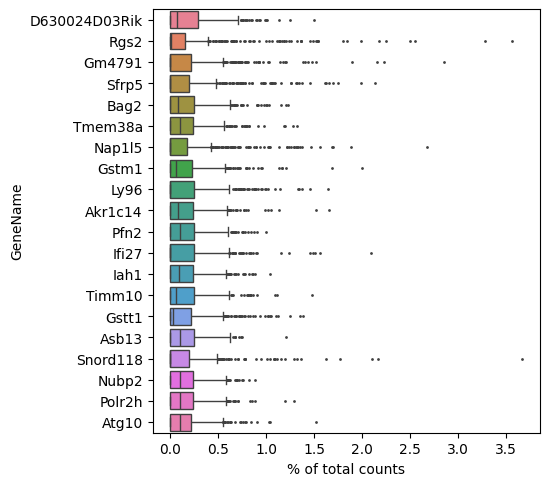

In [7]:
sc.pl.highest_expr_genes(adata, n_top=20)

## Use preprocess method provided by Psupertime

In [8]:
preprocessing_params = {"select_genes": "all", "log": True}
import anndata
from demo.Fig2_TemproalVAE_against_benchmark_methods.pypsupertime import Psupertime

print(f"Input Data: n_genes={adata.n_vars}, n_cells={adata.n_obs}")
# ------------------preprocess adata here
tp = Psupertime(n_jobs=5, n_folds=5,
                preprocessing_params=preprocessing_params
                )  # if for Acinar cell "select_genes": "all"

adata = tp.preprocessing.fit_transform(adata.copy())
del tp


Input Data: n_genes=3737, n_cells=575


In [9]:
adata

AnnData object with n_obs × n_vars = 575 × 3737
    obs: 'time'
    var: 'GeneName', 'n_cells', 'mean', 'std'
    uns: 'log1p'

## Train TemporalVAE with TemporalVAE

In [10]:
method = "tvae"
time_standard_type = "embryoneg5to5"  #
print(f"time standard type: {time_standard_type}")
if not os.path.exists(f'{os.getcwd()}/{method}_results'):
    os.makedirs(f'{os.getcwd()}/{method}_results')

time standard type: embryoneg5to5


In [11]:
import TemporalVAE

## Set model config and logger config

In [12]:
os.getcwd()

'/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE'

In [13]:
# ------- set config and logger ------
train_epoch_num = 60
import yaml
with open("vae_model_configs/supervise_vae_regressionclfdecoder_exp2_toyDataset.yaml", 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

In [14]:
import logging
from TemporalVAE.utils.logging_system  import  LogHelper
logger_file = f'{os.getcwd()}/logs/{method}_results/exp2_{dataset}.log'
if not os.path.exists(f'{os.getcwd()}/logs/{method}_results/'):
        os.makedirs(f'{os.getcwd()}/logs/{method}_results/')
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)
print("Finished setting up the logger at: {}.".format(logger_file))

Finished setting up the logger at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta.log.


In [15]:
print(f"Epoch number: {train_epoch_num}")
donor_list = list(np.unique(adata.obs["time"]))
donor_list

Epoch number: 60


[-1, 0, 3, 9, 15, 18, 60]

In [16]:
kFold_test_result_df = pd.DataFrame(columns=['time', 'pseudotime', 'trans_label'])

save_path = _logger.root.handlers[0].baseFilename.replace(".log", "")
save_path

'/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta'

## 1. If you want to do train on all donors and check the umap of latent space.


### Import necessary methods

In [17]:
from TemporalVAE.utils.GPU_manager_pytorch import auto_select_gpu_and_cpu, check_memory
from TemporalVAE.utils.utils_project import trans_time, plot_training_loss_for_tags
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning import seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pathlib import Path

import numpy as np
from TemporalVAE.model_master.experiment_temporalVAE import temporalVAEExperiment
from TemporalVAE.model_master.dataset import  SupervisedVAEDataset_onlyPredict
from TemporalVAE.model_master import vae_models

/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/lightning_fabric/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
2025-07-13 00:24:38,325 INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /mnt/yijun/nfs_share/yijun_tmp/tmpynm8d_v3 
2025-07-13 00:24:38,468 INFO - torch.distributed.nn.jit.instantiator - Writing /mnt/yijun/nfs_share/yijun_tmp/tmpynm8d_v3/_remote_module_non_scriptable.py 


### Define the save path of results

In [18]:
subFold_save_file_path = "{}/vae_results/all/".format(save_path)
if not os.path.exists(subFold_save_file_path):
    os.makedirs(subFold_save_file_path)
subFold_save_file_path

'/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/vae_results/all/'

### Transpose adata to tensor type for model training

In [19]:
# we need to transpose data to correct its shape
x_sc_train = torch.tensor(adata.X, dtype=torch.get_default_dtype()).t()
print("Set x_sc_train data with shape (gene, cells): {}".format(x_sc_train.shape))
y_time_train = x_sc_train.new_tensor(np.array(adata.obs["time"]).astype(int))
y_time_train

Set x_sc_train data with shape (gene, cells): torch.Size([3737, 575])


tensor([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  3.,  3.,
         3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  

### Normalized the time of each cell.

In [20]:
# for classification model with discrete time cannot use sigmoid and logit time type
y_time_nor_train, label_dic = trans_time(y_time_train, time_standard_type)
print("label dictionary: {}".format(label_dic))
print("Normalize train y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
      .format(time_standard_type, np.unique(y_time_train), y_time_train.shape, np.unique(y_time_nor_train)))
y_time_nor_train

label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 60: 5.0}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([575]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]


tensor([-5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000, -5.0000,
        -5.0000, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360, -4.8360,
        -4.8360, -4.8360, -4.8360, -4.83

### Set up structure of VAE model and Start train process

In [21]:
# ------------------------------------------- Set up VAE model and Start train process -------------------------------------------------
print("Start training with epoch: {}. ".format(train_epoch_num))

# if int(config['model_params']['in_channels']) == 0:
config['model_params']['in_channels'] = x_sc_train.shape[0]
tb_logger = TensorBoardLogger(save_dir=subFold_save_file_path,
                              name=config['model_params']['name'], )

# For reproducibility
seed_everything(config['exp_params']['manual_seed'], True)
MyVAEModel = vae_models[config['model_params']['name']](**config['model_params'])
MyVAEModel

2025-07-13 00:24:38,645 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


Start training with epoch: 60. 


SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial(
  (encoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=3737, out_features=3737, bias=True)
      (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=3737, out_features=3737, bias=True)
      (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Linear(in_features=3737, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (4): Sequential(
      (0)

### Set up training process parameters

In [22]:
train_data = [[x_sc_train[:, i], y_time_nor_train[i], y_time_train[i]] for i in range(x_sc_train.shape[1])]
from TemporalVAE.model_master.dataset import SupervisedVAEDataset_onlyTrain
data = SupervisedVAEDataset_onlyTrain(train_data=train_data, train_batch_size=len(train_data))

# data.setup("train")
experiment = temporalVAEExperiment(MyVAEModel, config['exp_params'])

lr_monitor = LearningRateMonitor()
check_memory()
device = auto_select_gpu_and_cpu()
print("Auto select run on {}".format(device))

runner = Trainer(logger=tb_logger, log_every_n_steps=1,
                 callbacks=[
                     lr_monitor,
                     ModelCheckpoint(save_top_k=2,
                                     dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
                                     monitor="val_loss",
                                     save_last=True),
                 ],
                 # check_val_every_n_epoch=1, val_check_interval=1,
                 devices=[int(device.split(":")[-1])] if device!="cpu" else "auto",
                 accelerator="gpu" if device!="cpu" else "cpu", max_epochs=train_epoch_num
                 )

Path(f"{tb_logger.log_dir}/Samples").mkdir(exist_ok=True, parents=True)
Path(f"{tb_logger.log_dir}/Reconstructions").mkdir(exist_ok=True, parents=True)

2025-07-13 00:24:38,983 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-13 00:24:38,985 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-13 00:24:38,985 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-13 00:24:38,986 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 


Free Memory Percentage: 67.96%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 39.369GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 39.369GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 39.369GB
Auto select run on cuda:2


### Starting training.

In [23]:

print(f"======= Training {config['model_params']['name']} =======")
runner.fit(experiment, data)

# test the model
data_predict = SupervisedVAEDataset_onlyPredict(predict_data=train_data, predict_batch_size=len(train_data))
train_result = runner.predict(experiment, data_predict)
train_clf_result, train_latent_mu_result, train_latent_log_var_result = train_result[0][0], train_result[0][1], \
    train_result[0][2]

======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
2025-07-13 00:24:39,410 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 00:24:40,346 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-13 00:24:40,349 INFO - pytorch_lightning.callbacks.model_summary - 
  | Name  | Type                                                         | Params
--------------------------------

Training: 0it [00:00, ?it/s]

Epoch train loss: {'train_loss_step': tensor(87.9330, device='cuda:2'), 'train_Reconstruction_loss_step': tensor(1.3852, device='cuda:2'), 'train_KLD_step': tensor(-6.0102, device='cuda:2'), 'train_clf_loss_step': tensor(17.3092, device='cuda:2'), 'train_loss_epoch': tensor(87.9330, device='cuda:2'), 'train_Reconstruction_loss_epoch': tensor(1.3852, device='cuda:2'), 'train_KLD_epoch': tensor(-6.0102, device='cuda:2'), 'train_clf_loss_epoch': tensor(17.3092, device='cuda:2')}


/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:359: UserWarning: `ModelCheckpoint(monitor='val_loss')` could not find the monitored key in the returned metrics: ['train_loss', 'train_loss_step', 'train_Reconstruction_loss', 'train_Reconstruction_loss_step', 'train_KLD', 'train_KLD_step', 'train_clf_loss', 'train_clf_loss_step', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch', 'epoch', 'step']. HINT: Did you call `log('val_loss', value)` in the `LightningModule`?
  warning_cache.warn(m)


Epoch train loss: {'train_loss_step': tensor(86.7805, device='cuda:2'), 'train_Reconstruction_loss_step': tensor(1.3686, device='cuda:2'), 'train_KLD_step': tensor(-6.3802, device='cuda:2'), 'train_clf_loss_step': tensor(17.0821, device='cuda:2'), 'train_loss_epoch': tensor(86.7805, device='cuda:2'), 'train_Reconstruction_loss_epoch': tensor(1.3686, device='cuda:2'), 'train_KLD_epoch': tensor(-6.3802, device='cuda:2'), 'train_clf_loss_epoch': tensor(17.0821, device='cuda:2')}
Epoch train loss: {'train_loss_step': tensor(82.6145, device='cuda:2'), 'train_Reconstruction_loss_step': tensor(1.2873, device='cuda:2'), 'train_KLD_step': tensor(-7.3201, device='cuda:2'), 'train_clf_loss_step': tensor(16.2651, device='cuda:2'), 'train_loss_epoch': tensor(82.6145, device='cuda:2'), 'train_Reconstruction_loss_epoch': tensor(1.2873, device='cuda:2'), 'train_KLD_epoch': tensor(-7.3201, device='cuda:2'), 'train_clf_loss_epoch': tensor(16.2651, device='cuda:2')}
Epoch train loss: {'train_loss_step': 

2025-07-13 00:26:49,560 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=60` reached. 
2025-07-13 00:26:49,968 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 00:26:50,077 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, predict_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which 

Predicting: 0it [00:00, ?it/s]

### Clear cache

In [24]:
del runner
del experiment
# 清除CUDA缓存
torch.cuda.empty_cache()

In [25]:
MyVAEModel

SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial(
  (encoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=3737, out_features=3737, bias=True)
      (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=3737, out_features=3737, bias=True)
      (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Linear(in_features=3737, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (4): Sequential(
      (0)

In [26]:
adata

AnnData object with n_obs × n_vars = 575 × 3737
    obs: 'time'
    var: 'GeneName', 'n_cells', 'mean', 'std'
    uns: 'log1p'

... storing 'time_group' as categorical


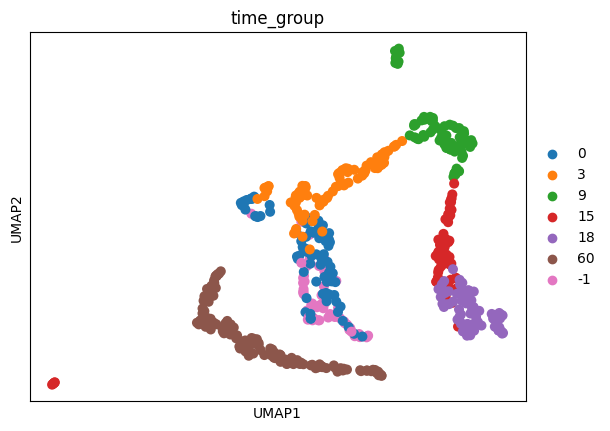

In [27]:
#train_clf_result, train_latent_mu_result
adata1 = adata.copy()
adata1.obsm['X_pca'] = train_latent_mu_result.cpu().data.numpy()
adata1.obs["time_group"] = adata1.obs['time'].values.astype('str')

sc.pp.neighbors(adata1, n_neighbors=5, n_pcs=10,random_state=0)
sc.tl.umap(adata1,random_state=0)

sc.pl.umap(adata1, color=["time_group"])

## If you want to do multiple loop calculations: test on one donor and train on other donors.


## Define a function: test on one donor and train on other donors.

In [28]:
# def process_fold_toyDataset(fold, donor_list, adata, time_standard_type, config, save_path, train_epoch_num):
#     from TemporalVAE.utils.GPU_manager_pytorch import auto_select_gpu_and_cpu, check_memory
#     from TemporalVAE.utils.utils_project import trans_time, plot_training_loss_for_tags
#     import torch
#     from pytorch_lightning import Trainer
#     from pytorch_lightning.loggers import TensorBoardLogger
#     from pytorch_lightning import seed_everything
#     from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
#     from pathlib import Path
#
#     import numpy as np
#     from TemporalVAE.model_master.experiment_temporalVAE import temporalVAEExperiment
#     from TemporalVAE.model_master.dataset import SupervisedVAEDataset, SupervisedVAEDataset_onlyPredict
#     from TemporalVAE.model_master import vae_models
#     # _logger = logging.getLogger(__name__)
#     # time.sleep(random.randint(5, 20))
#     print("the {}/{} fold train, use donor-{} as test set".format(fold + 1, len(donor_list), donor_list[fold]))
#
#     train_adata = adata[adata.obs["time"] != donor_list[fold]].copy()
#     test_adata = adata[adata.obs["time"] == donor_list[fold]].copy()
#     # move one cell from test to train to occupy the test time
#     one_test_cell = test_adata[:5].copy()
#     test_adata = test_adata[5:].copy()
#     train_adata = anndata.concat([train_adata.copy(), one_test_cell.copy()], axis=0)
#
#     # ----------------------------------------split Train and Test dataset-----------------------------------------------------
#     print("the {}/{} fold train, use donor-{} as test set".format(fold + 1, len(donor_list), donor_list[fold]))
#     subFold_save_file_path = "{}/vae_results/{}/".format(save_path,
#                                                          donor_list[fold])
#
#     if not os.path.exists(subFold_save_file_path):
#         os.makedirs(subFold_save_file_path)
#     # we need to transpose data to correct its shape
#     x_sc_train = torch.tensor(train_adata.X, dtype=torch.get_default_dtype()).t()
#     x_sc_test = torch.tensor(test_adata.X, dtype=torch.get_default_dtype()).t()
#     print("Set x_sc_train data with shape (gene, cells): {}".format(x_sc_train.shape))
#     print("Set x_sc_test data with shape (gene, cells): {}".format(x_sc_test.shape))
#
#     # trans y_time
#
#     y_time_train = x_sc_train.new_tensor(np.array(train_adata.obs["time"]).astype(int))
#     y_time_test = x_sc_test.new_tensor(np.array(test_adata.obs["time"]).astype(int))
#
#     # for classification model with discrete time cannot use sigmoid and logit time type
#     y_time_nor_train, label_dic = trans_time(y_time_train, time_standard_type, capture_time_other=y_time_test)
#     y_time_nor_test, label_dic = trans_time(y_time_test, time_standard_type, label_dic_train=label_dic)
#     print("label dictionary: {}".format(label_dic))
#     print("Normalize train y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
#           .format(time_standard_type, np.unique(y_time_train), y_time_train.shape, np.unique(y_time_nor_train)))
#     print("Normalize test y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
#           .format(time_standard_type, np.unique(y_time_test), y_time_test.shape, np.unique(y_time_nor_test)))
#
#     # ------------------------------------------- Set up VAE model and Start train process -------------------------------------------------
#     print("Start training with epoch: {}. ".format(train_epoch_num))
#
#     # if int(config['model_params']['in_channels']) == 0:
#     config['model_params']['in_channels'] = x_sc_train.shape[0]
#     tb_logger = TensorBoardLogger(save_dir=subFold_save_file_path,
#                                   name=config['model_params']['name'], )
#
#     # For reproducibility
#     seed_everything(config['exp_params']['manual_seed'], True)
#
#     MyVAEModel = vae_models[config['model_params']['name']](**config['model_params'])
#
#     ## print parameters of model
#     # for name, param in MyVAEModel.named_parameters():
#     #     print(name, param)
#     train_data = [[x_sc_train[:, i], y_time_nor_train[i], y_time_train[i]] for i in range(x_sc_train.shape[1])]
#     test_data = [[x_sc_test[:, i], y_time_nor_test[i], y_time_test[i]] for i in range(x_sc_test.shape[1])]
#     print("don't set batch")
#     data = SupervisedVAEDataset(train_data=train_data, val_data=test_data, test_data=test_data, predict_data=test_data,
#                                 train_batch_size=len(train_data), val_batch_size=len(test_data),
#                                 test_batch_size=len(test_data), predict_batch_size=len(test_data),
#                                 label_dic=label_dic)
#
#     # data.setup("train")
#     experiment = temporalVAEExperiment(MyVAEModel, config['exp_params'])
#
#     # 创建一个 LearningRateMonitor 回调实例
#     lr_monitor = LearningRateMonitor()
#     # 2023-09-07 20:34:25 add check memory
#     check_memory()
#     device = auto_select_gpu_and_cpu()
#     print("Auto select run on {}".format(device))
#
#     runner = Trainer(logger=tb_logger, log_every_n_steps=1,
#                      callbacks=[
#                          lr_monitor,
#                          ModelCheckpoint(save_top_k=2,
#                                          dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
#                                          monitor="val_loss",
#                                          save_last=True),
#                      ],
#                      # check_val_every_n_epoch=1, val_check_interval=1,
#                      devices=[int(device.split(":")[-1])],
#                      accelerator="gpu", max_epochs=train_epoch_num
#                      )
#
#     Path(f"{tb_logger.log_dir}/Samples").mkdir(exist_ok=True, parents=True)
#     Path(f"{tb_logger.log_dir}/Reconstructions").mkdir(exist_ok=True, parents=True)
#
#     print(f"======= Training {config['model_params']['name']} =======")
#     runner.fit(experiment, data)
#
#     # test the model
#     print("this epoch final, on test data:{}".format(runner.test(experiment, data)))
#     # predict on train data
#     data_predict = SupervisedVAEDataset_onlyPredict(predict_data=train_data, predict_batch_size=len(train_data))
#     train_result = runner.predict(experiment, data_predict)
#     train_clf_result, train_latent_mu_result, train_latent_log_var_result = train_result[0][0], train_result[0][1], \
#         train_result[0][2]
#     # predict on test data
#     data_test = SupervisedVAEDataset_onlyPredict(predict_data=test_data, predict_batch_size=len(test_data))
#     test_result = runner.predict(experiment, data_test)
#     test_clf_result, test_latent_mu_result, test_latent_log_var_result = test_result[0][0], test_result[0][1], \
#         test_result[0][2]
#     if (np.isnan(np.squeeze(test_clf_result)).any()):
#         print("The Array contain NaN values")
#     else:
#         print("The Array does not contain NaN values")
#     print("predicted time of test donor is continuous.")
#
#     _result_df = pd.DataFrame({'time': donor_list[fold],  # First column with a constant value of 1
#                                'pseudotime': np.squeeze(test_clf_result, axis=1)})
#
#     # _result_df['pseudotime'] = _result_df['pseudotime_normalized'].apply(denormalize, args=(min(label_dic.keys()), max(label_dic.keys()), min(label_dic.values()), max(label_dic.values())))
#     _result_df["trans_label"] = _result_df["time"].map(label_dic)
#     print("Plot training loss line for check.")
#
#     from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
#     tags = EventAccumulator(tb_logger.log_dir).Reload().Tags()['scalars']
#     print("All tags in logger: {}".format(tags))
#     # Retrieve and print the metric results
#     plot_tag_list = list(set(["train_clf_loss_epoch", "val_clf_loss", "test_clf_loss_epoch"]) & set(tags))
#     print(f"plot tags {plot_tag_list}")
#     plot_training_loss_for_tags(tb_logger, plot_tag_list, special_str=donor_list[fold], title=donor_list[fold])
#
#     # ---------------------------------------------- save sub model parameters for check  --------------------------------------------------
#     print("encoder and decoder structure: {}".format({"encoder": MyVAEModel.encoder, "decoder": MyVAEModel.decoder}))
#     print("clf-decoder structure: {}".format({"encoder": MyVAEModel.clf_decoder}))
#     torch.save(MyVAEModel, tb_logger.root_dir + "/version_" + str(tb_logger.version) + '/model.pth')
#     print("detail information about structure save at： {}".format(
#         tb_logger.root_dir + "/version_" + str(tb_logger.version) + '/model.pth'))
#
#
#     del runner
#     del experiment
#     # 清除CUDA缓存
#     torch.cuda.empty_cache()
#     return _result_df,MyVAEModel,test_latent_mu_result

In [29]:
from TemporalVAE.model_master.dataset import SupervisedVAEDataset
def process_fold_toyDataset(fold, donor_list, adata, time_standard_type, config, save_path, train_epoch_num):
    # _logger = logging.getLogger(__name__)
    # time.sleep(random.randint(5, 20))
    print("the {}/{} fold train, use donor-{} as test set".format(fold + 1, len(donor_list), donor_list[fold]))

    train_adata = adata[adata.obs["time"] != donor_list[fold]].copy()
    test_adata = adata[adata.obs["time"] == donor_list[fold]].copy()
    # move one cell from test to train to occupy the test time
    one_test_cell = test_adata[:5].copy()
    test_adata = test_adata[5:].copy()
    train_adata = anndata.concat([train_adata.copy(), one_test_cell.copy()], axis=0)

    # ----------------------------------------split Train and Test dataset-----------------------------------------------------
    print("the {}/{} fold train, use donor-{} as test set".format(fold + 1, len(donor_list), donor_list[fold]))
    subFold_save_file_path = f"{save_path}/temporalVAE_results/{donor_list[fold]}/"

    if not os.path.exists(subFold_save_file_path):
        os.makedirs(subFold_save_file_path)
    # we need to transpose data to correct its shape
    x_sc_train = torch.tensor(train_adata.X, dtype=torch.get_default_dtype()).t()
    x_sc_test = torch.tensor(test_adata.X, dtype=torch.get_default_dtype()).t()
    print("Set x_sc_train data with shape (gene, cells): {}".format(x_sc_train.shape))
    print("Set x_sc_test data with shape (gene, cells): {}".format(x_sc_test.shape))

    # trans y_time

    y_time_train = x_sc_train.new_tensor(np.array(train_adata.obs["time"]).astype(int))
    y_time_test = x_sc_test.new_tensor(np.array(test_adata.obs["time"]).astype(int))

    # for classification model with discrete time cannot use sigmoid and logit time type
    y_time_nor_train, label_dic = trans_time(y_time_train, time_standard_type, capture_time_other=y_time_test)
    y_time_nor_test, label_dic = trans_time(y_time_test, time_standard_type, label_dic_train=label_dic)
    print("label dictionary: {}".format(label_dic))
    print("Normalize train y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
          .format(time_standard_type, np.unique(y_time_train), y_time_train.shape, np.unique(y_time_nor_train)))
    print("Normalize test y_time_nor_train type: {}, with y_time_nor_train lable: {}, shape: {}, \ndetail: {}"
          .format(time_standard_type, np.unique(y_time_test), y_time_test.shape, np.unique(y_time_nor_test)))

    # ------------------------------------------- Set up temporalVAE model and Start train process -------------------------------------------------
    print("Start training with epoch: {}. ".format(train_epoch_num))

    # if int(config['model_params']['in_channels']) == 0:
    config['model_params']['in_channels'] = x_sc_train.shape[0]
    tb_logger = TensorBoardLogger(save_dir=subFold_save_file_path,
                                  name=config['model_params']['name'], )

    # For reproducibility
    seed_everything(config['exp_params']['manual_seed'], True)

    MyVAEModel = vae_models[config['model_params']['name']](**config['model_params'])

    ## print parameters of model
    # for name, param in MyVAEModel.named_parameters():
    #     print(name, param)
    train_data = [[x_sc_train[:, i], y_time_nor_train[i], y_time_train[i]] for i in range(x_sc_train.shape[1])]
    test_data = [[x_sc_test[:, i], y_time_nor_test[i], y_time_test[i]] for i in range(x_sc_test.shape[1])]
    print("don't set batch")
    data = SupervisedVAEDataset(train_data=train_data, val_data=test_data, test_data=test_data, predict_data=test_data,
                                train_batch_size=len(train_data), val_batch_size=len(test_data),
                                test_batch_size=len(test_data), predict_batch_size=len(test_data),
                                label_dic=label_dic)

    # data.setup("train")
    experiment = temporalVAEExperiment(MyVAEModel, config['exp_params'])

    # 创建一个 LearningRateMonitor 回调实例
    lr_monitor = LearningRateMonitor()
    # 2023-09-07 20:34:25 add check memory
    check_memory()
    device = auto_select_gpu_and_cpu()
    print("Auto select run on {}".format(device))

    runner = Trainer(logger=tb_logger, log_every_n_steps=1,
                     callbacks=[
                         lr_monitor,
                         ModelCheckpoint(save_top_k=2,
                                         dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
                                         monitor="val_loss",
                                         save_last=True),
                     ],
                     # check_val_every_n_epoch=1, val_check_interval=1,
                     devices=[int(device.split(":")[-1])],
                     accelerator="gpu", max_epochs=train_epoch_num
                     )

    Path(f"{tb_logger.log_dir}/Samples").mkdir(exist_ok=True, parents=True)
    Path(f"{tb_logger.log_dir}/Reconstructions").mkdir(exist_ok=True, parents=True)

    print(f"======= Training {config['model_params']['name']} =======")
    runner.fit(experiment, data)

    # test the model
    print("this epoch final, on test data:{}".format(runner.test(experiment, data)))
    # predict on train data
    data_predict = SupervisedVAEDataset_onlyPredict(predict_data=train_data, predict_batch_size=len(train_data))
    train_result = runner.predict(experiment, data_predict)
    train_clf_result, train_latent_mu_result, train_latent_log_var_result = train_result[0][0], train_result[0][1], \
        train_result[0][2]
    # predict on test data
    data_test = SupervisedVAEDataset_onlyPredict(predict_data=test_data, predict_batch_size=len(test_data))
    test_result = runner.predict(experiment, data_test)
    test_clf_result, test_latent_mu_result, test_latent_log_var_result = test_result[0][0], test_result[0][1], \
        test_result[0][2]
    if (np.isnan(np.squeeze(test_clf_result)).any()):
        print("The Array contain NaN values")
    else:
        print("The Array does not contain NaN values")
    print("predicted time of test donor is continuous.")

    _result_df = pd.DataFrame({'time': donor_list[fold],  # First column with a constant value of 1
                               'pseudotime': np.squeeze(test_clf_result, axis=1)})
    # _result_df['pseudotime'] = _result_df['pseudotime_normalized'].apply(denormalize, args=(min(label_dic.keys()), max(label_dic.keys()), min(label_dic.values()), max(label_dic.values())))
    _result_df["trans_label"] = _result_df["time"].map(label_dic)
    print("Plot training loss line for check.")

    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    tags = EventAccumulator(tb_logger.log_dir).Reload().Tags()['scalars']
    print("All tags in logger: {}".format(tags))
    # Retrieve and print the metric results
    plot_tag_list = list(set(["train_clf_loss_epoch", "val_clf_loss", "test_clf_loss_epoch"]) & set(tags))
    print(f"plot tags {plot_tag_list}")
    plot_training_loss_for_tags(tb_logger, plot_tag_list, special_str=donor_list[fold], title=donor_list[fold])

    # ---------------------------------------------- save sub model parameters for check  --------------------------------------------------
    print("encoder and decoder structure: {}".format({"encoder": MyVAEModel.encoder, "decoder": MyVAEModel.decoder}))
    print("clf-decoder structure: {}".format({"encoder": MyVAEModel.clf_decoder}))
    torch.save(MyVAEModel, tb_logger.root_dir + "/version_" + str(tb_logger.version) + '/model.pth')
    print("detail information about structure save at： {}".format(
        tb_logger.root_dir + "/version_" + str(tb_logger.version) + '/model.pth'))

    del MyVAEModel
    del runner
    del experiment
    # 清除CUDA缓存
    torch.cuda.empty_cache()
    return _result_df

2025-07-13 00:26:57,945 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


the 1/7 fold train, use donor--1 as test set
the 1/7 fold train, use donor--1 as test set
Set x_sc_train data with shape (gene, cells): torch.Size([3737, 519])
Set x_sc_test data with shape (gene, cells): torch.Size([3737, 56])
label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 60: 5.0}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([519]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]
Normalize test y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.], shape: torch.Size([56]), 
detail: [-5.]
Start training with epoch: 60. 


2025-07-13 00:26:58,265 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-13 00:26:58,265 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-13 00:26:58,266 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-13 00:26:58,266 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2025-07-13 00:26:58,273 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 


don't set batch
Free Memory Percentage: 67.45%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.865GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 39.369GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 39.369GB
Auto select run on cuda:1
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


2025-07-13 00:26:59,050 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-13 00:26:59,053 INFO - pytorch_lightning.callbacks.model_summary - 
  | Name  | Type                                                         | Params
---------------------------------------------------------------------------------------
0 | model | SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial | 44.0 M
---------------------------------------------------------------------------------------
44.0 M    Trainable params
0         Non-trainable params
44.0 M    Total params
175.829   Total estimated model params size (MB) 


...

2025-07-13 00:30:18,646 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 00:30:18,699 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 00:30:19,124 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/-1/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1752384419.GPU2.3928161.1 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/-1/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1752384617.GPU2.3928161.2 
2025-07-13 00:30:19,126 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/-1/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1752384617.GPU2.3928161.2 
2025-07-13 00:30:19,127 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 00:30:19,155 INFO - tensorboard - Directory watche

The Array does not contain NaN values
predicted time of test donor is continuous.
Plot training loss line for check.
All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'val_loss', 'val_Reconstruction_loss', 'val_KLD', 'val_clf_loss', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch', 'test_loss_step', 'test_Reconstruction_loss_step', 'test_KLD_step', 'test_clf_loss_step', 'test_loss_epoch', 'test_Reconstruction_loss_epoch', 'test_KLD_epoch', 'test_clf_loss_epoch']
plot tags ['val_clf_loss', 'train_clf_loss_epoch', 'test_clf_loss_epoch']


2025-07-13 00:30:19,353 INFO - TemporalVAE.utils.utils_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/-1/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/trainingLoss_val_clf_loss_train_clf_loss_epoch_test_clf_loss_epoch_-1.png 


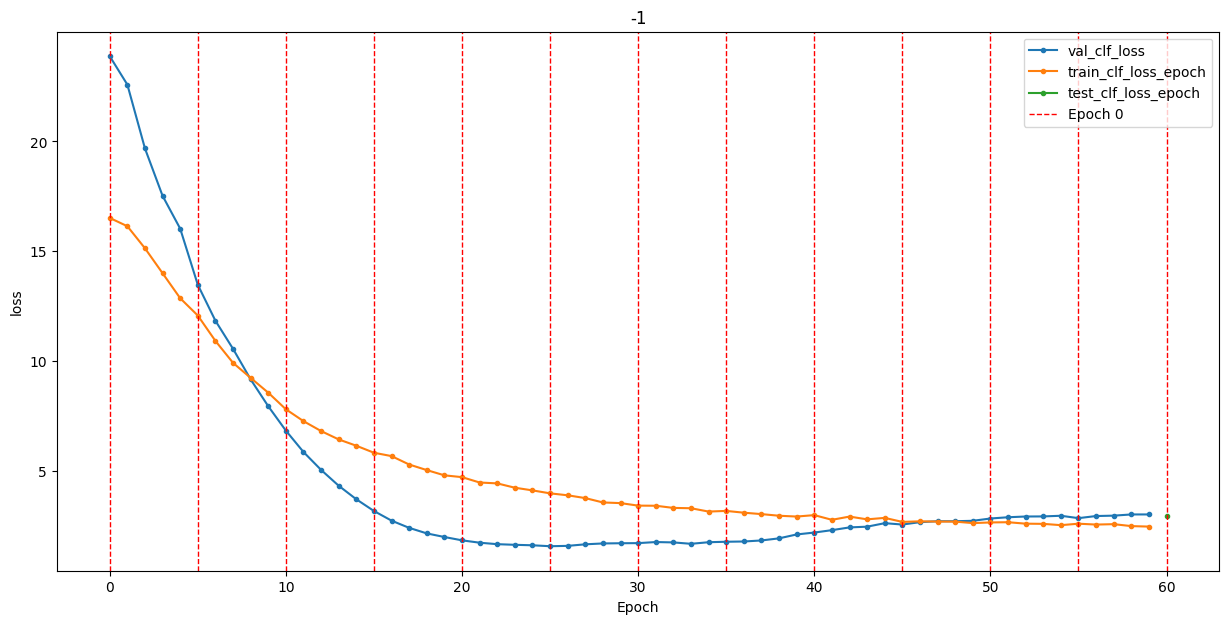

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_3928161/4157090726.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  kFold_test_result_df = pd.concat([kFold_test_result_df, _result_df], axis=0)
2025-07-13 00:30:19,944 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


encoder and decoder structure: {'encoder': Sequential(
  (0): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
  )
  (1): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Linear(in_features=3737, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(6

2025-07-13 00:30:20,268 WARNING - pytorch_lightning.loggers.tensorboard - Missing logger folder: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial 
2025-07-13 00:30:20,338 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-13 00:30:20,338 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-13 00:30:20,339 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-13 00:30:20,339 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2025-07-13 00:30:20,344 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for perf

don't set batch
Free Memory Percentage: 67.25%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.865GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.863GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 38.865GB
Auto select run on cuda:2
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

...

2025-07-13 00:33:23,319 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 00:33:23,380 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 00:33:23,784 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752384620.GPU2.3928161.3 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752384802.GPU2.3928161.4 
2025-07-13 00:33:23,786 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752384802.GPU2.3928161.4 
2025-07-13 00:33:23,786 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 00:33:23,814 INFO - tensorboard - Directory watcher a

The Array does not contain NaN values
predicted time of test donor is continuous.
Plot training loss line for check.
All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'val_loss', 'val_Reconstruction_loss', 'val_KLD', 'val_clf_loss', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch', 'test_loss_step', 'test_Reconstruction_loss_step', 'test_KLD_step', 'test_clf_loss_step', 'test_loss_epoch', 'test_Reconstruction_loss_epoch', 'test_KLD_epoch', 'test_clf_loss_epoch']
plot tags ['val_clf_loss', 'train_clf_loss_epoch', 'test_clf_loss_epoch']


2025-07-13 00:33:24,016 INFO - TemporalVAE.utils.utils_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/trainingLoss_val_clf_loss_train_clf_loss_epoch_test_clf_loss_epoch_0.png 


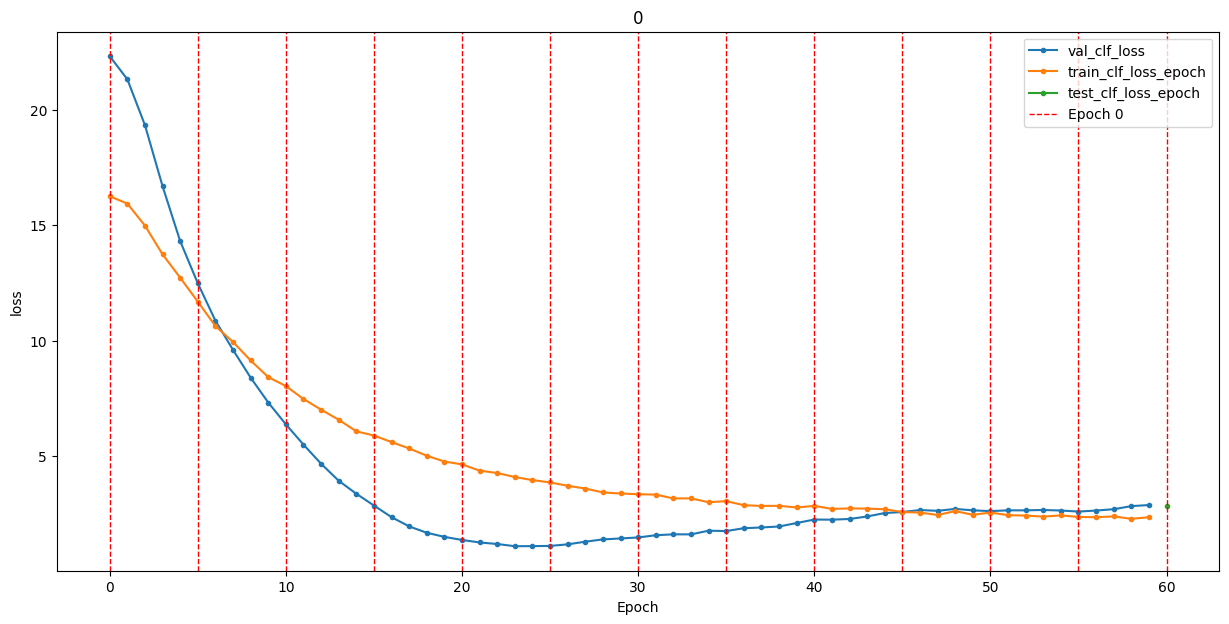

encoder and decoder structure: {'encoder': Sequential(
  (0): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
  )
  (1): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Linear(in_features=3737, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(6

2025-07-13 00:33:24,590 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


detail information about structure save at： /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/model.pth
the 3/7 fold train, use donor-3 as test set
the 3/7 fold train, use donor-3 as test set
Set x_sc_train data with shape (gene, cells): torch.Size([3737, 492])
Set x_sc_test data with shape (gene, cells): torch.Size([3737, 83])
label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 60: 5.0}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([492]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]
Normalize test y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [3.], shape: torch.Size([83]), 
detail: [-4.344]
Start training with epoch: 60. 


2025-07-13 00:33:24,876 WARNING - pytorch_lightning.loggers.tensorboard - Missing logger folder: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/3/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial 
2025-07-13 00:33:24,944 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-13 00:33:24,944 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-13 00:33:24,945 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-13 00:33:24,945 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2025-07-13 00:33:24,950 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for perf

don't set batch
Free Memory Percentage: 67.01%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.863GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 38.863GB
Auto select run on cuda:1
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


...

2025-07-13 00:36:30,726 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 00:36:30,777 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 00:36:31,175 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/3/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752384804.GPU2.3928161.5 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/3/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752384989.GPU2.3928161.6 
2025-07-13 00:36:31,177 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/3/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752384989.GPU2.3928161.6 
2025-07-13 00:36:31,178 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 00:36:31,213 INFO - tensorboard - Directory watcher a

The Array does not contain NaN values
predicted time of test donor is continuous.
Plot training loss line for check.
All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'val_loss', 'val_Reconstruction_loss', 'val_KLD', 'val_clf_loss', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch', 'test_loss_step', 'test_Reconstruction_loss_step', 'test_KLD_step', 'test_clf_loss_step', 'test_loss_epoch', 'test_Reconstruction_loss_epoch', 'test_KLD_epoch', 'test_clf_loss_epoch']
plot tags ['val_clf_loss', 'train_clf_loss_epoch', 'test_clf_loss_epoch']


2025-07-13 00:36:31,462 INFO - TemporalVAE.utils.utils_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/3/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/trainingLoss_val_clf_loss_train_clf_loss_epoch_test_clf_loss_epoch_3.png 


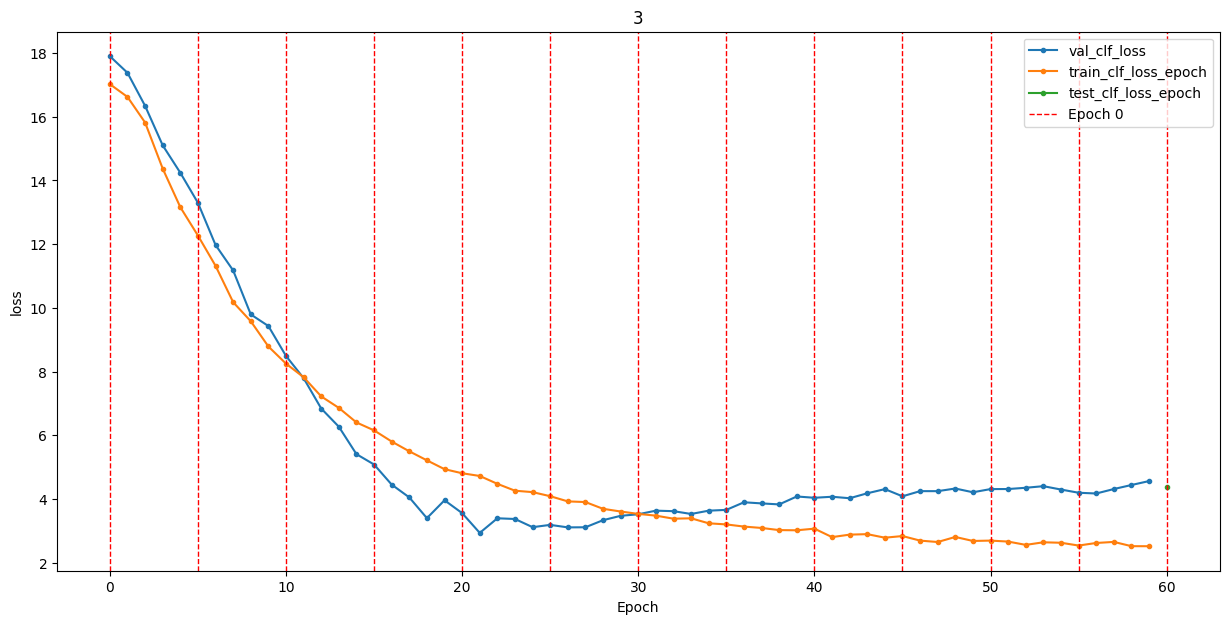

encoder and decoder structure: {'encoder': Sequential(
  (0): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
  )
  (1): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Linear(in_features=3737, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(6

2025-07-13 00:36:32,198 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


detail information about structure save at： /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/3/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/model.pth
the 4/7 fold train, use donor-9 as test set
the 4/7 fold train, use donor-9 as test set
Set x_sc_train data with shape (gene, cells): torch.Size([3737, 499])
Set x_sc_test data with shape (gene, cells): torch.Size([3737, 76])
label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 60: 5.0}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([499]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]
Normalize test y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [9.], shape: torch.Size([76]), 
detail: [-3.361]
Start training with epoch: 60. 


2025-07-13 00:36:32,481 WARNING - pytorch_lightning.loggers.tensorboard - Missing logger folder: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/9/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial 
2025-07-13 00:36:32,511 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-13 00:36:32,511 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-13 00:36:32,511 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-13 00:36:32,512 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2025-07-13 00:36:32,577 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for perf

don't set batch
Free Memory Percentage: 66.56%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.192GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.863GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 38.863GB
Auto select run on cuda:1
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


...

Predicting: 0it [00:00, ?it/s]

The Array does not contain NaN values
predicted time of test donor is continuous.
Plot training loss line for check.


2025-07-13 00:39:43,401 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/9/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752384992.GPU2.3928161.7 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/9/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385181.GPU2.3928161.8 
2025-07-13 00:39:43,403 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/9/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385181.GPU2.3928161.8 
2025-07-13 00:39:43,403 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 00:39:43,432 INFO - tensorboard - Directory watcher a

All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'val_loss', 'val_Reconstruction_loss', 'val_KLD', 'val_clf_loss', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch', 'test_loss_step', 'test_Reconstruction_loss_step', 'test_KLD_step', 'test_clf_loss_step', 'test_loss_epoch', 'test_Reconstruction_loss_epoch', 'test_KLD_epoch', 'test_clf_loss_epoch']
plot tags ['val_clf_loss', 'train_clf_loss_epoch', 'test_clf_loss_epoch']


2025-07-13 00:39:43,630 INFO - TemporalVAE.utils.utils_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/9/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/trainingLoss_val_clf_loss_train_clf_loss_epoch_test_clf_loss_epoch_9.png 


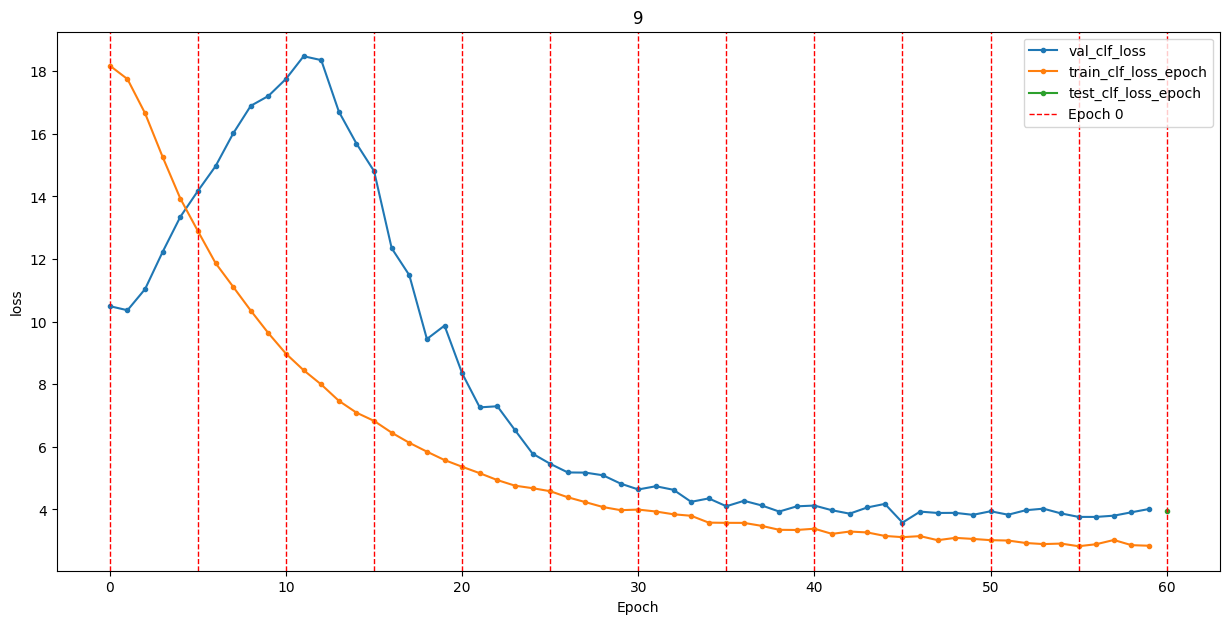

encoder and decoder structure: {'encoder': Sequential(
  (0): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
  )
  (1): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Linear(in_features=3737, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(6

2025-07-13 00:39:44,230 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


detail information about structure save at： /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/9/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/model.pth
the 5/7 fold train, use donor-15 as test set
the 5/7 fold train, use donor-15 as test set
Set x_sc_train data with shape (gene, cells): torch.Size([3737, 521])
Set x_sc_test data with shape (gene, cells): torch.Size([3737, 54])
label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 60: 5.0}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([521]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]
Normalize test y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [15.], shape: torch.Size([54]), 
detail: [-2.377]
Start training with epoch: 60. 


2025-07-13 00:39:44,518 WARNING - pytorch_lightning.loggers.tensorboard - Missing logger folder: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/15/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial 
2025-07-13 00:39:44,569 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-13 00:39:44,570 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-13 00:39:44,570 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-13 00:39:44,571 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2025-07-13 00:39:44,575 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for per

don't set batch
Free Memory Percentage: 67.25%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.865GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 38.865GB
Auto select run on cuda:2
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


...

2025-07-13 00:42:22,500 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 00:42:22,563 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 00:42:22,986 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/15/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385184.GPU2.3928161.9 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/15/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385341.GPU2.3928161.10 
2025-07-13 00:42:22,987 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/15/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385341.GPU2.3928161.10 
2025-07-13 00:42:22,988 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 00:42:23,016 INFO - tensorboard - Directory watc

The Array does not contain NaN values
predicted time of test donor is continuous.
Plot training loss line for check.
All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'val_loss', 'val_Reconstruction_loss', 'val_KLD', 'val_clf_loss', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch', 'test_loss_step', 'test_Reconstruction_loss_step', 'test_KLD_step', 'test_clf_loss_step', 'test_loss_epoch', 'test_Reconstruction_loss_epoch', 'test_KLD_epoch', 'test_clf_loss_epoch']
plot tags ['val_clf_loss', 'train_clf_loss_epoch', 'test_clf_loss_epoch']


2025-07-13 00:42:23,226 INFO - TemporalVAE.utils.utils_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/15/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/trainingLoss_val_clf_loss_train_clf_loss_epoch_test_clf_loss_epoch_15.png 


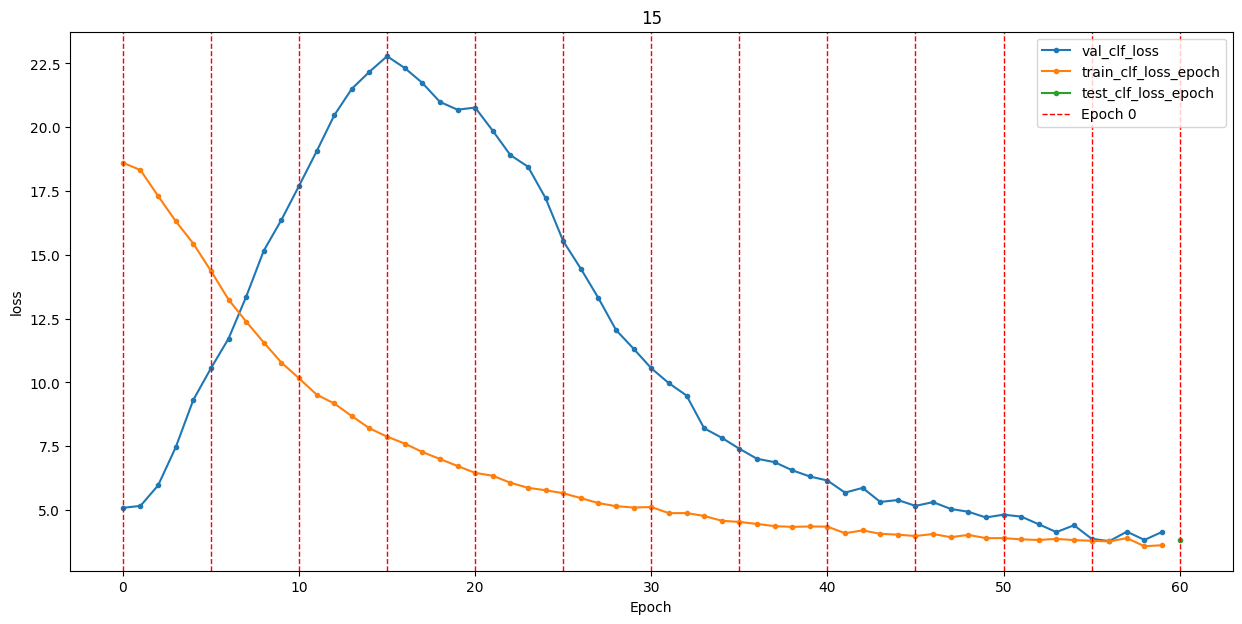

encoder and decoder structure: {'encoder': Sequential(
  (0): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
  )
  (1): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Linear(in_features=3737, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(6

2025-07-13 00:42:23,836 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


detail information about structure save at： /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/15/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/model.pth
the 6/7 fold train, use donor-18 as test set
the 6/7 fold train, use donor-18 as test set
Set x_sc_train data with shape (gene, cells): torch.Size([3737, 509])
Set x_sc_test data with shape (gene, cells): torch.Size([3737, 66])
label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 60: 5.0}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([509]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]
Normalize test y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [18.], shape: torch.Size([66]), 
detail: [-1.885]
Start training with epoch: 60. 


2025-07-13 00:42:24,116 WARNING - pytorch_lightning.loggers.tensorboard - Missing logger folder: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/18/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial 
2025-07-13 00:42:24,167 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-13 00:42:24,168 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-13 00:42:24,168 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-13 00:42:24,169 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2025-07-13 00:42:24,173 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for per

don't set batch
Free Memory Percentage: 67.18%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.863GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 38.863GB
Auto select run on cuda:2
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


...

2025-07-13 00:44:36,374 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 00:44:36,426 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 00:44:36,827 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/18/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385344.GPU2.3928161.11 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/18/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385475.GPU2.3928161.12 
2025-07-13 00:44:36,829 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/18/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385475.GPU2.3928161.12 
2025-07-13 00:44:36,829 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 00:44:36,858 INFO - tensorboard - Directory wat

The Array does not contain NaN values
predicted time of test donor is continuous.
Plot training loss line for check.
All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'val_loss', 'val_Reconstruction_loss', 'val_KLD', 'val_clf_loss', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch', 'test_loss_step', 'test_Reconstruction_loss_step', 'test_KLD_step', 'test_clf_loss_step', 'test_loss_epoch', 'test_Reconstruction_loss_epoch', 'test_KLD_epoch', 'test_clf_loss_epoch']
plot tags ['val_clf_loss', 'train_clf_loss_epoch', 'test_clf_loss_epoch']


2025-07-13 00:44:37,059 INFO - TemporalVAE.utils.utils_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/18/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/trainingLoss_val_clf_loss_train_clf_loss_epoch_test_clf_loss_epoch_18.png 


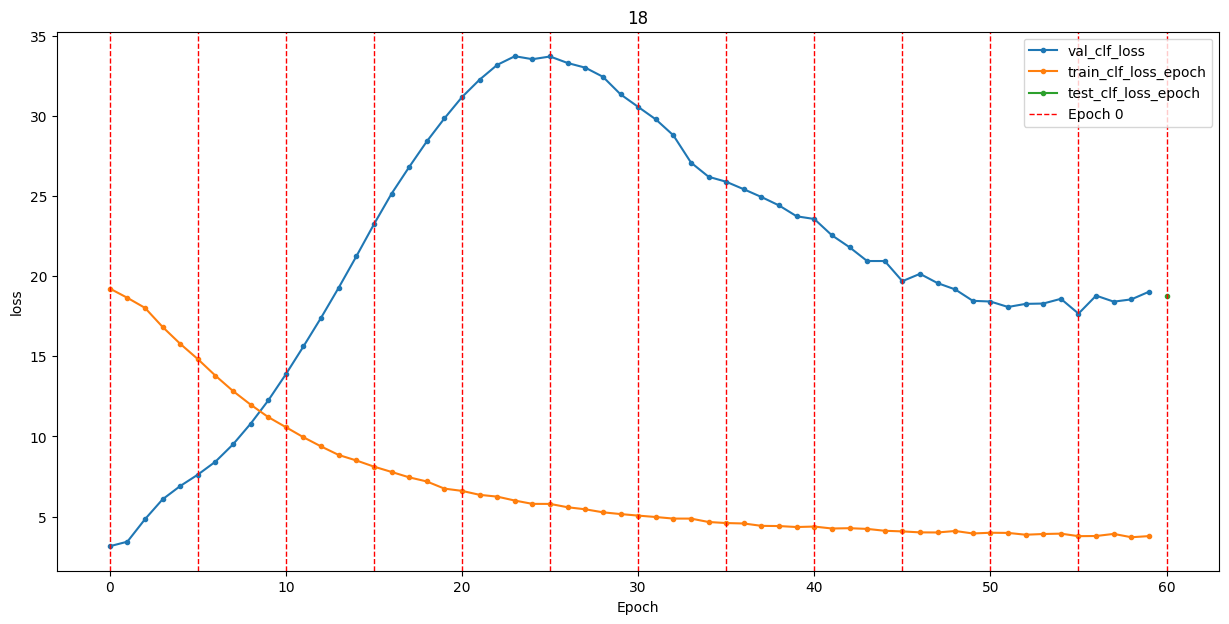

encoder and decoder structure: {'encoder': Sequential(
  (0): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
  )
  (1): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Linear(in_features=3737, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(6

2025-07-13 00:44:37,639 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 


detail information about structure save at： /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/18/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/model.pth
the 7/7 fold train, use donor-60 as test set
the 7/7 fold train, use donor-60 as test set
Set x_sc_train data with shape (gene, cells): torch.Size([3737, 449])
Set x_sc_test data with shape (gene, cells): torch.Size([3737, 126])
label dictionary: {-1: -5.0, 0: -4.836, 3: -4.344, 9: -3.361, 15: -2.377, 18: -1.885, 60: 5.0}
Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [-1.  0.  3.  9. 15. 18. 60.], shape: torch.Size([449]), 
detail: [-5.    -4.836 -4.344 -3.361 -2.377 -1.885  5.   ]
Normalize test y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [60.], shape: torch.Size([126]), 
detail: [5.]
Start training with epoch: 60. 


2025-07-13 00:44:37,917 WARNING - pytorch_lightning.loggers.tensorboard - Missing logger folder: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/60/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial 
2025-07-13 00:44:37,968 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-13 00:44:37,968 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-13 00:44:37,968 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-13 00:44:37,969 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2025-07-13 00:44:37,973 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for per

don't set batch
Free Memory Percentage: 67.08%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 38.863GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.861GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 25.221GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 38.863GB
Auto select run on cuda:2
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


...

2025-07-13 00:47:41,227 INFO - pytorch_lightning.utilities.rank_zero - You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision 
2025-07-13 00:47:41,317 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2025-07-13 00:47:41,743 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/60/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385478.GPU2.3928161.13 to /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/60/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385660.GPU2.3928161.14 
2025-07-13 00:47:41,746 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/60/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1752385660.GPU2.3928161.14 
2025-07-13 00:47:41,746 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-13 00:47:41,773 INFO - tensorboard - Directory wat

The Array does not contain NaN values
predicted time of test donor is continuous.
Plot training loss line for check.
All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'val_loss', 'val_Reconstruction_loss', 'val_KLD', 'val_clf_loss', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch', 'test_loss_step', 'test_Reconstruction_loss_step', 'test_KLD_step', 'test_clf_loss_step', 'test_loss_epoch', 'test_Reconstruction_loss_epoch', 'test_KLD_epoch', 'test_clf_loss_epoch']
plot tags ['val_clf_loss', 'train_clf_loss_epoch', 'test_clf_loss_epoch']


2025-07-13 00:47:41,981 INFO - TemporalVAE.utils.utils_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/logs/tvae_results/exp2_embryoBeta/temporalVAE_results/60/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/trainingLoss_val_clf_loss_train_clf_loss_epoch_test_clf_loss_epoch_60.png 


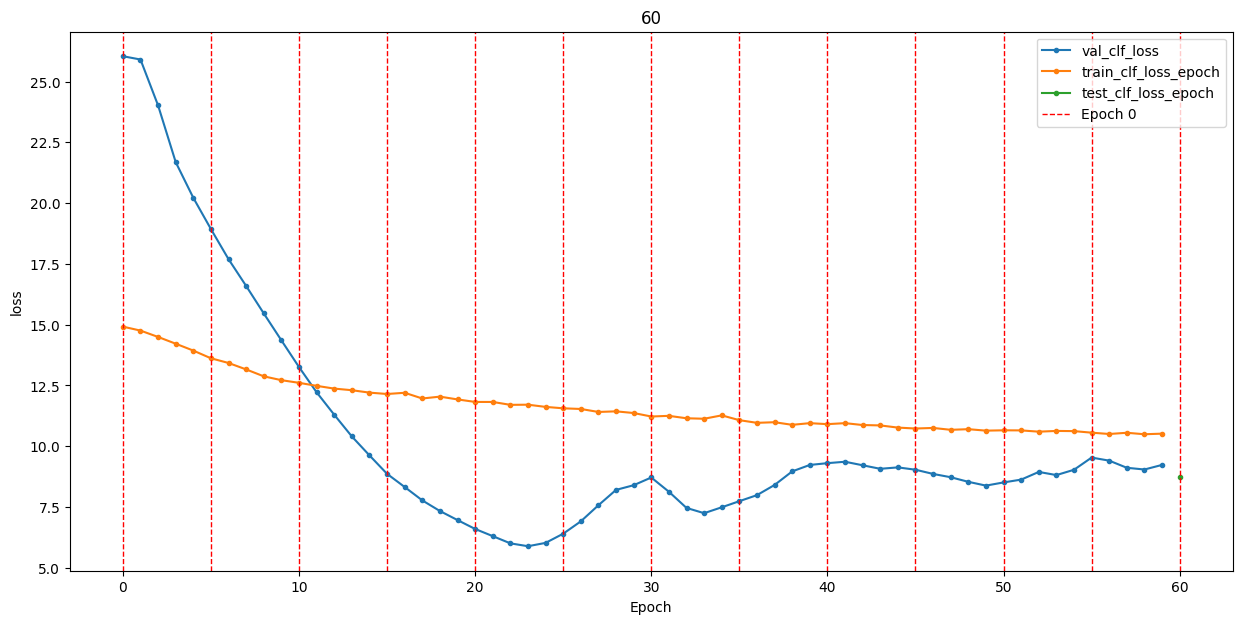

encoder and decoder structure: {'encoder': Sequential(
  (0): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
  )
  (1): Sequential(
    (0): Linear(in_features=3737, out_features=3737, bias=True)
    (1): BatchNorm1d(3737, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Linear(in_features=3737, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(6

,time,pseudotime,trans_label
0,-1,-3.413869,-5.0
1,-1,-3.219765,-5.0
2,-1,-3.384326,-5.0
3,-1,-3.284833,-5.0
4,-1,-3.615200,-5.0
...,...,...,...
121,60,1.578337,5.0
122,60,0.942082,5.0
123,60,0.892572,5.0
124,60,4.662192,5.0


In [30]:
for fold in range(len(donor_list)):
    _result_df= process_fold_toyDataset(fold, donor_list, adata, time_standard_type, config, save_path, train_epoch_num)
    kFold_test_result_df = pd.concat([kFold_test_result_df, _result_df], axis=0)
print("k-fold test final result:")
kFold_test_result_df

spearman correlation score: 0.932788291869457, p-value: 1.3573877555223933e-240.
kendalltau correlation score: 0.8013037001251352,p-value: 1.28783073906612e-148.
test result save at /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/tvae_results/embryoBeta_tvae_result.csv


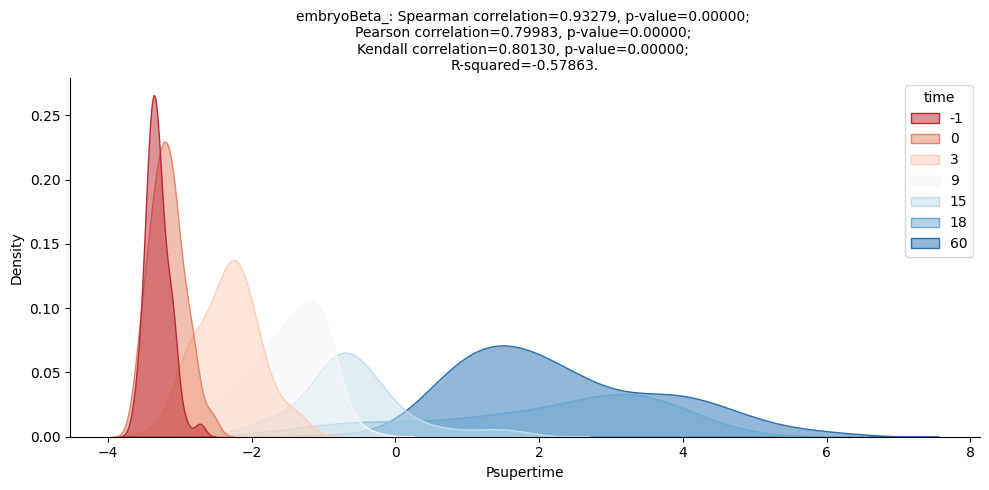

figure save at /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/tvae_results//embryoBeta__labelsOverPsupertime.png
figure save at /mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE/tvae_results//embryoBeta_labelsOverPsupertime.png


In [31]:
def corr(x1, x2):
    from scipy.stats import spearmanr, kendalltau
    sp_correlation, sp_p_value = spearmanr(x1, x2)
    ke_correlation, ke_p_value = kendalltau(x1, x2)
    print(f"spearman correlation score: {sp_correlation}, p-value: {sp_p_value}.")
    print(f"kendalltau correlation score: {ke_correlation},p-value: {ke_p_value}.")

corr(kFold_test_result_df["time"], kFold_test_result_df["pseudotime"])
kFold_test_result_df.to_csv(f'{os.getcwd()}/{method}_results/{dataset}_{method}_result.csv', index=True)
print(f"test result save at {os.getcwd()}/{method}_results/{dataset}_{method}_result.csv")

# f = tp.plot_grid_search(title="Grid Search")
# f.savefig(f"{os.getcwd()}/psupertime_results/gridSearch.png")
# f = tp.plot_model_perf((adata.X, adata.obs.time), figsize=(6, 5))
# f.savefig(f"{os.getcwd()}/psupertime_results/modelPred.png")
# f = tp.plot_identified_gene_coefficients(adata, n_top=20)
# f.savefig(f"{os.getcwd()}/psupertime_results/geneCoff.png")
from TemporalVAE.utils.utils_plot import plot_psupertime_density
save_path = f"{os.getcwd()}/{method}_results/"
plot_psupertime_density(kFold_test_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=f"{dataset}_")
print(f"figure save at {save_path}/{dataset}_labelsOverPsupertime.png")